In [108]:
# import libraries
import pandas as pd
import numpy as np

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [109]:
df = pd.read_csv('heart.csv')
df.head()

,Unnamed: 0,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,0,63,Male,3,145,233,1,0,150,0,2.3,0,0,1,Higher Risk
1,1,37,Male,2,130,250,0,1,187,0,3.5,0,0,2,Higher Risk
2,2,41,Female,1,130,204,0,0,172,0,1.4,2,0,2,Higher Risk
3,3,56,Male,1,120,236,0,1,178,0,0.8,2,0,2,Higher Risk
4,4,57,Female,0,120,354,0,1,163,1,0.6,2,0,2,Higher Risk


### Question 1
Generate a bar chart showing the number of men and women with high and low risk of heart attack.

Text(0, 0.5, 'Amount')

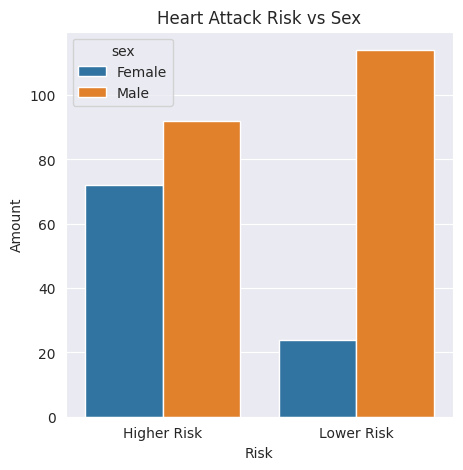

In [110]:
plt.rcParams['figure.figsize'] = [5,5]
sns.set_style('darkgrid')
count = df.groupby(['output','sex']).size().reset_index(name='count')
sns.barplot(x='output',y='count', hue='sex', data=count, errorbar=None)
plt.title('Heart Attack Risk vs Sex')
plt.xlabel('Risk')
plt.ylabel('Amount')

### Question 2
Create two side-by-side pie charts showing how men and women are divided percentage-wise in terms of cardiac risk.

Text(0.5, 1.0, 'Heart attack risk for women')

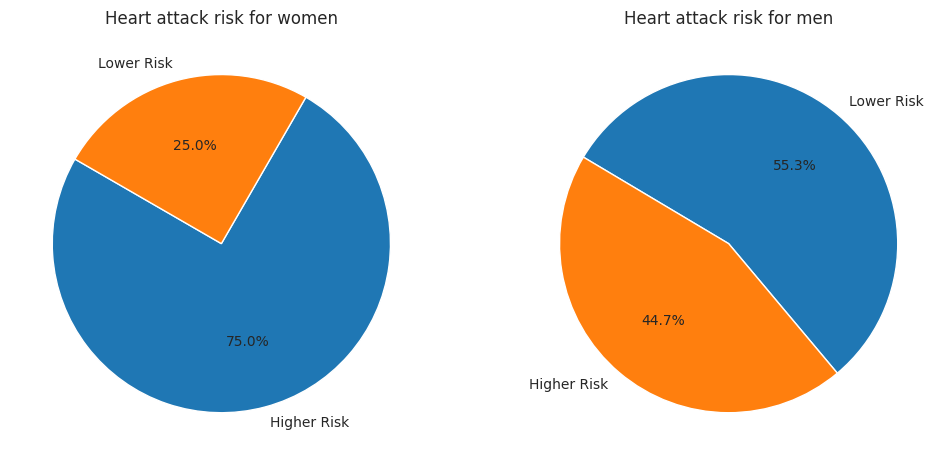

In [111]:
mulheres = df[df['sex'] == 'Female']['output'].value_counts(normalize=True) * 100
homens = df[df['sex'] == 'Male']['output'].value_counts(normalize=True) * 100


fig, axs = plt.subplots(1,2, figsize=(12,6))

axs[1].pie(homens, labels=homens.index, autopct='%1.1f%%', startangle=310)
axs[1].set_title('Heart attack risk for men')

axs[0].pie(mulheres, labels=mulheres.index, autopct='%1.1f%%', startangle=150)
axs[0].set_title('Heart attack risk for women')

### Question 3
Create a pie chart showing the distribution of cardiac risk (High Risk) between men and women according to the dataset. Note that the dataset has more male data, which impacts the result.

Text(0.5, 1.0, 'High Risk of Heart Attack - Men vs Women')

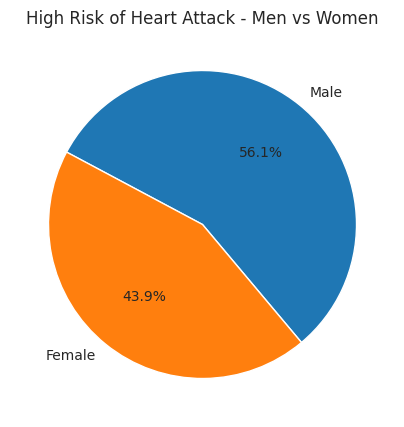

In [112]:
total = df[df['output'] == 'Higher Risk']
countTotal = total['sex'].value_counts()

plt.pie(countTotal, labels=countTotal.index, autopct='%1.1f%%', startangle=310)
plt.title('High Risk of Heart Attack - Men vs Women')


### Question 4
Create two side-by-side bar charts showing the age distributions of men and women in the dataset.

Text(0, 0.5, 'Count')

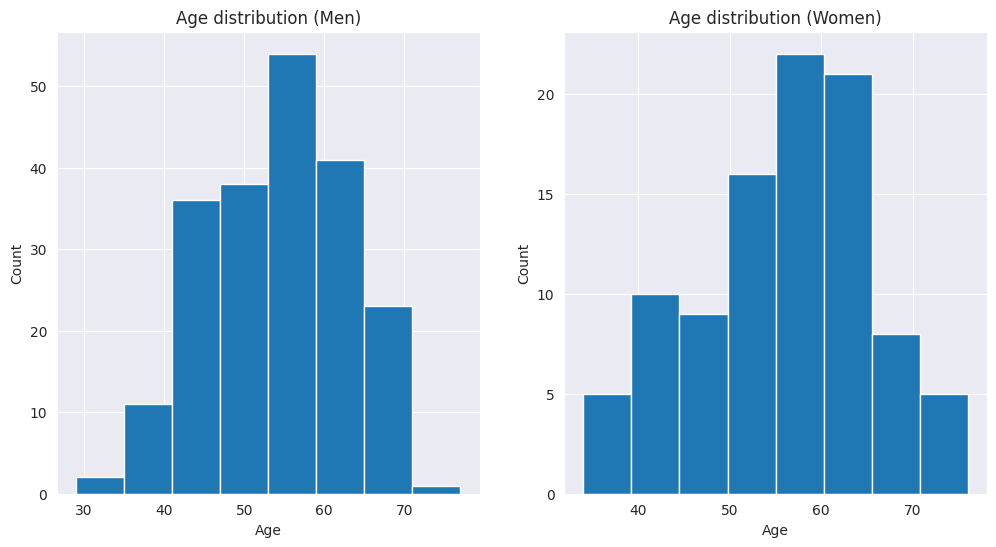

In [113]:
mulheres = df[df['sex'] == 'Female']['age']
homens = df[df['sex'] == 'Male']['age']

fig, axs = plt.subplots(1,2, figsize=(12,6))

axs[0].hist(homens, bins = 8)
axs[0].set_title('Age distribution (Men)')
axs[0].set_xlabel('Age')
axs[0].set_ylabel('Count')

axs[1].hist(mulheres, bins = 8)
axs[1].set_title('Age distribution (Women)')
axs[1].set_xlabel('Age')
axs[1].set_ylabel('Count')

### Question 5
Considering the cholesterol (chol) of patients in the dataset, remove outliers with values above 500. Then, show a scatter plot relating age and cholesterol values of patients.

Text(0, 0.5, 'Cholesterol of patients')

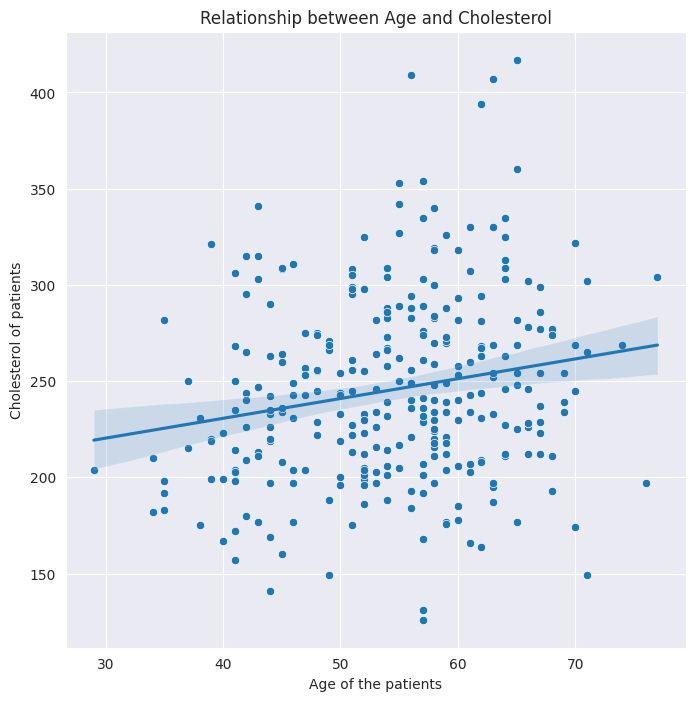

In [114]:
df1 = df[df['chol'] <= 500]

plt.figure(figsize=(8,8))
sns.scatterplot(data=df1,x='age',y='chol')
sns.regplot(data=df1, x='age',y='chol', scatter=False)
plt.title('Relationship between Age and Cholesterol')
plt.xlabel('Age of the patients')
plt.ylabel('Cholesterol of patients')


### Question 6
The column 'cp' stands for 'chest pain'. There are 4 types of cp (0 - 3). We want to know if there is a relationship between the patient's blood pressure (trtbps) and the type of chest pain presented. Create a bar chart showing the average blood pressure of patients by chest pain type and gender.

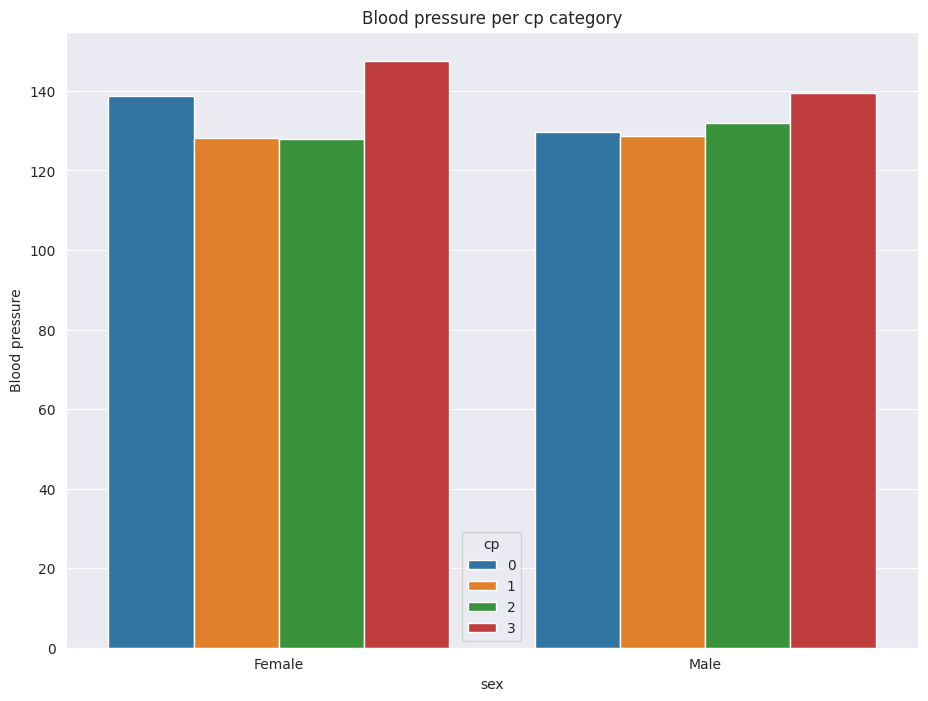

In [115]:
mean_pressure = df.groupby(['cp','sex'])['trtbps'].mean().reset_index()

plt.figure(figsize=(11,8))
sns.barplot(data=mean_pressure, x='sex',y='trtbps',hue='cp')
plt.title('Blood pressure per cp category')
plt.ylabel('Blood pressure')
plt.legend(loc='lower center', title='cp')
